In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from rake_nltk import Rake
import nltk
import matplotlib.pyplot as plt

# Loading to db
# importing os module for environment variables
import os
# importing necessary functions from dotenv library
from dotenv import load_dotenv 
# loading variables from .env file
load_dotenv() 
import psycopg2
from sqlalchemy import create_engine

# Larger Pull Clinical Trials

In [3]:
ct_df = pd.read_csv("/Users/shantibrodnick/Downloads/510Capstone/GenderDisparityinResearch/data/raw/raw_clinical_trials_data.csv")

In [34]:
ct_df.info()
# 373,282 rows

<class 'pandas.DataFrame'>
RangeIndex: 373282 entries, 0 to 373281
Data columns (total 18 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   nct_number       373282 non-null  str           
 1   title            373282 non-null  str           
 2   study_status     373282 non-null  str           
 3   summary          373282 non-null  str           
 4   conditions       373280 non-null  str           
 5   pom              363741 non-null  str           
 6   sponsor          373282 non-null  str           
 7   collaborators    125975 non-null  str           
 8   sex              373122 non-null  str           
 9   age              373282 non-null  str           
 10  enrollment       370212 non-null  float64       
 11  funder_type      373282 non-null  str           
 12  study_type       373282 non-null  str           
 13  start_date       373282 non-null  datetime64[us]
 14  completion_date  365288 non-nul

## date EDA 

In [5]:
ct_df['start_date'] = pd.to_datetime(ct_df['start_date'])
ct_df['completion_date'] = pd.to_datetime(ct_df['completion_date'])

In [6]:
ct_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 373282 entries, 0 to 373281
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   nct_number       373282 non-null  str           
 1   title            373282 non-null  str           
 2   study_status     373282 non-null  str           
 3   summary          373282 non-null  str           
 4   conditions       373280 non-null  str           
 5   pom              363741 non-null  str           
 6   sponsor          373282 non-null  str           
 7   collaborators    125975 non-null  str           
 8   sex              373122 non-null  str           
 9   age              373282 non-null  str           
 10  enrollment       370212 non-null  float64       
 11  funder_type      373282 non-null  str           
 12  study_type       373282 non-null  str           
 13  start_date       373282 non-null  datetime64[us]
 14  completion_date  365288 non-nul

In [7]:
ct_df['start_year'] = ct_df['start_date'].dt.year
ct_df['completion_year'] = ct_df['completion_date'].dt.year

In [8]:
ct_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 373282 entries, 0 to 373281
Data columns (total 17 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   nct_number       373282 non-null  str           
 1   title            373282 non-null  str           
 2   study_status     373282 non-null  str           
 3   summary          373282 non-null  str           
 4   conditions       373280 non-null  str           
 5   pom              363741 non-null  str           
 6   sponsor          373282 non-null  str           
 7   collaborators    125975 non-null  str           
 8   sex              373122 non-null  str           
 9   age              373282 non-null  str           
 10  enrollment       370212 non-null  float64       
 11  funder_type      373282 non-null  str           
 12  study_type       373282 non-null  str           
 13  start_date       373282 non-null  datetime64[us]
 14  completion_date  365288 non-nul

In [ ]:
# Find min and max year
print(ct_df['start_year'].min()) # 1948
print(ct_df['completion_year'].max()) # 2100

1948
2100.0


In [8]:
print(ct_df['completion_year'].head())
print(ct_df['start_year'].head())

0    1987.0
1    2040.0
2    1994.0
3    1989.0
4    1991.0
Name: completion_year, dtype: float64
0    1982
1    1983
2    1983
3    1983
4    1983
Name: start_year, dtype: int32


In [9]:
ct_df['completion_year'] = ct_df['completion_year'].astype('Int64')

In [10]:
print(ct_df['completion_year'].head())

0    1987
1    2040
2    1994
3    1989
4    1991
Name: completion_year, dtype: Int64


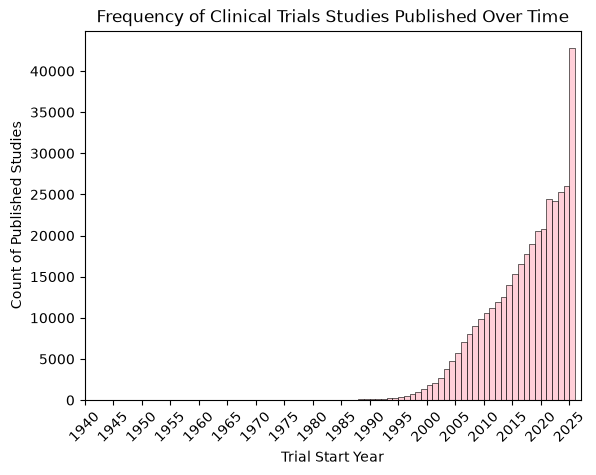

In [61]:
sns.histplot(ct_df, x = 'start_year', binwidth=1, color='pink')
plt.xlim(1940, 2027)
plt.xticks(np.arange(1940, 2027, step = 5), rotation=45)
plt.xlabel("Trial Start Year")
plt.ylabel("Count of Published Studies")
plt.title("Frequency of Clinical Trials Studies Published Over Time")
plt.show()

<Axes: xlabel='completion_year', ylabel='Count'>

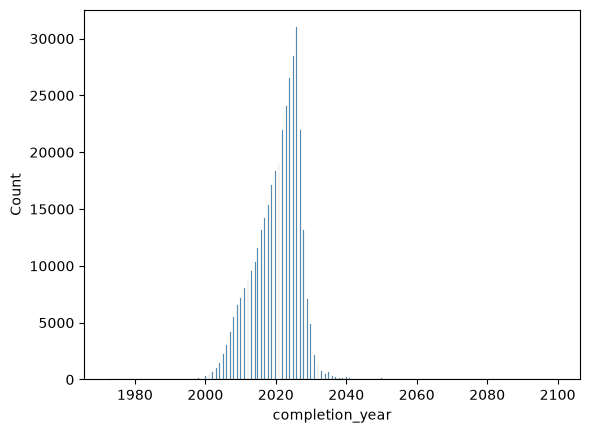

In [12]:
sns.histplot(ct_df, x = 'completion_year')

## pom EDA 

In [32]:
ct_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 373282 entries, 0 to 373281
Data columns (total 18 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   nct_number       373282 non-null  str           
 1   title            373282 non-null  str           
 2   study_status     373282 non-null  str           
 3   summary          373282 non-null  str           
 4   conditions       373280 non-null  str           
 5   pom              363741 non-null  str           
 6   sponsor          373282 non-null  str           
 7   collaborators    125975 non-null  str           
 8   sex              373122 non-null  str           
 9   age              373282 non-null  str           
 10  enrollment       370212 non-null  float64       
 11  funder_type      373282 non-null  str           
 12  study_type       373282 non-null  str           
 13  start_date       373282 non-null  datetime64[us]
 14  completion_date  365288 non-nul

In [ ]:
ct_df['pom'].isna().sum()
# 9541
# pom stands for primary outcome measures

np.int64(9541)